# Sentiment Analysis Final Project
## Critic Reviews of *The Passion of the Christ* and Biblical Epic Films

**Final Project — Delores Bledsoe**
**File name on submission:** `FP_PassionOfTheChrist_DeloresBledsoe.ipynb`

---

## Project Overview

This notebook builds an end-to-end sentiment analysis pipeline:

- **Analyze** critic reviews of *The Passion of the Christ* (2004) and comparable biblical/religious epic films
- **Preprocess** the review text using standard NLP techniques
- **Build and compare** multiple classification models
- **Evaluate** model performance using multiple metrics
- **Communicate** findings in a business context

## Project Requirements Checklist

- **Dataset:** Rotten Tomatoes critic reviews (public, Kaggle) — text data + Fresh/Rotten label
- **Models:** at least 2 classification models (this notebook trains 3)
- **Evaluation:** accuracy, precision, recall, F1, and a confusion matrix for each model
- **Documentation:** markdown cells throughout explaining approach, findings, and insights

---


       **PROJECT DEFINITION**

* **Business Problem:**
Religious and biblical epic films are a recurrin, commercially significant genre, but they consistently draw polarized critical reaction whereas some entries earn near-unanimous acclaim, others get torn apart by critics over tone, accuracy, or execution.
This project asks wether a critic review's sentiment(positive vs. negative) can be predicted directly from its text. Using The Passion of the Christ (2004) being one of the most polarizing and commercially significant religious films ever released as the flagship title, alongside a set of comparable biblical/religious epics, this project builds a text classification pipeline that a studio, marketing team, or distributor could use to quickly guage critical reception at scale and to understood what language in a review tends to drive praise versus critism in this genre.       

**Dataset Description:**


*  Dataset Name: Rotten Tomatoes Movies and Critic Reviews
*  Source: Kaggle, uploaded stefanoleone992(link)
*  Number of samples: The full dataset spans critic reviews for roughly 17,000+movies; once filtered to The Passion of the Christ and the comparable biblical/religious epics in scope for this project, the working sample size is printed by the Total reviews cell after the notebook runs and the exact count depends on which target titles actually appear in the data.
* Text Type: Professional critic review excerpts as one row per critic per film (the short pull-quote-style snippet Rotten Tomatoes displays, not the full original review).
*  Sentimental Labels: review_type, Rotten Tomatoes' own editorial classification of Fresh (positive) or Rotten (negative); recoded in this notebook as a binary sentiment column (1 = positive, 0 = negative).





**Importance and Real-World Applications:**

Critical reception meaningfully shapes a film's marketing strategy, awards positioning, and even box office trajectory which is especially for polarizing release like The Passion of the Christ, where critical and audience reaction diverged sharply along religious lines. A model that reliably classifies review sentiment from text alone gives studios and PR teams a way to triage large volumes of press coverage quickly around a release window instead of reading every review by hand. Beyond marketing, this kind of model can support competitive analysis of how one religious epic's reception compares to others in the genre, inform pull-quote/trailer selection, and act as an early-warning signal if reviews start trending negative during a rollout.

## Watch First: Trailers & Clips

*The Passion of the Christ* (dir. Mel Gibson, 2004) depicts the final twelve hours of the life of Jesus of Nazareth. A few official trailers, for context before reading the review data below:

- [Official Trailer (HD)](https://www.youtube.com/watch?v=puS0X6A8TKc)
- [Official Classic Trailer — 4K remaster, Newmarket Films](https://www.youtube.com/watch?v=QvLw-XQY3wI)
- [Extended Trailer](https://www.youtube.com/watch?v=K83366UdtXw)

> **Note:** This film is rated "R" for graphic, sustained violence depicting the crucifixion. Proceed with caution and at your own risk.


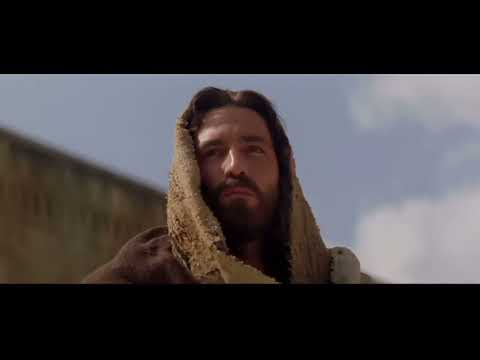

In [ ]:
from IPython.display import YouTubeVideo

# Official classic trailer, embedded for quick reference
YouTubeVideo('QvLw-XQY3wI', width=700, height=394)


---
## Setup

Run this notebook in **Google Colab**. The cells below install/import everything needed and download the dataset from Kaggle.

**Before running:** you need a free Kaggle account and API token.
1. Go to kaggle.com → your profile picture → *Settings* → *API* → *Create New Token*. This downloads `kaggle.json`.
2. When prompted by `kagglehub` below, upload that file (or place it at `~/.kaggle/kaggle.json`).


In [ ]:
# Install dependencies
!pip install -q kagglehub wordcloud


In [ ]:
import pandas as pd
import numpy as np
import re
import string
import time
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42

print("Libraries imported successfully!")


Libraries imported successfully!


In [ ]:
import kagglehub

# Downloads the "Rotten Tomatoes movies and critic reviews" dataset (Stefano Leone, Kaggle)
path = kagglehub.dataset_download('stefanoleone992/rotten-tomatoes-movies-and-critic-reviews-dataset')
print("Dataset downloaded to:", path)

import os
print(os.listdir(path))


100%|██████████| 77.2M/77.2M [00:00<00:00, 181MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/stefanoleone992/rotten-tomatoes-movies-and-critic-reviews-dataset/versions/1
['rotten_tomatoes_movies.csv', 'rotten_tomatoes_critic_reviews.csv']


In [ ]:
movies = pd.read_csv(f'{path}/rotten_tomatoes_movies.csv')
reviews = pd.read_csv(f'{path}/rotten_tomatoes_critic_reviews.csv')

print(movies.shape, reviews.shape)
movies.head()


(17712, 22) (1130017, 8)


,rotten_tomatoes_link,movie_title,movie_info,critics_consensus,content_rating,genres,directors,authors,actors,original_release_date,...,production_company,tomatometer_status,tomatometer_rating,tomatometer_count,audience_status,audience_rating,audience_count,tomatometer_top_critics_count,tomatometer_fresh_critics_count,tomatometer_rotten_critics_count
0,m/0814255,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,...,20th Century Fox,Rotten,49.0,149.0,Spilled,53.0,254421.0,43,73,76
1,m/0878835,Please Give,Kate (Catherine Keener) and her husband Alex (...,Nicole Holofcener's newest might seem slight i...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",2010-04-30,...,Sony Pictures Classics,Certified-Fresh,87.0,142.0,Upright,64.0,11574.0,44,123,19
2,m/10,10,"A successful, middle-aged Hollywood songwriter...",Blake Edwards' bawdy comedy may not score a pe...,R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert ...",1979-10-05,...,Waner Bros.,Fresh,67.0,24.0,Spilled,53.0,14684.0,2,16,8
3,m/1000013-12_angry_men,12 Angry Men (Twelve Angry Men),Following the closing arguments in a murder tr...,Sidney Lumet's feature debut is a superbly wri...,NR,"Classics, Drama",Sidney Lumet,Reginald Rose,"Martin Balsam, John Fiedler, Lee J. Cobb, E.G....",1957-04-13,...,Criterion Collection,Certified-Fresh,100.0,54.0,Upright,97.0,105386.0,6,54,0
4,m/1000079-20000_leagues_under_the_sea,"20,000 Leagues Under The Sea","In 1866, Professor Pierre M. Aronnax (Paul Luk...","One of Disney's finest live-action adventures,...",G,"Action & Adventure, Drama, Kids & Family",Richard Fleischer,Earl Felton,"James Mason, Kirk Douglas, Paul Lukas, Peter L...",1954-01-01,...,Disney,Fresh,89.0,27.0,Upright,74.0,68918.0,5,24,3


---
# Part 1: Project Definition

## Objectives
- Define the business problem you're solving.
##* The core problem is Film production studios and marketing teams face high financial risks when releasing polarizing or culturally sensitive genres, such as biblical and religious epics. Insights supported for this sentiment analysis identifies specific linguistic patterns, themes, and keywords that drive profesional critics to either praise or criticize a film in this specific genre. Decision Enabled marketing agencies can craft targeted promotional campaigns that highlight well-recieved themeatic elements, while creative executives can better navigate narrative choices that traditionally trigger negative critical reception. The target users that film studio executives, screenwriters, producers, and theatrical marketing teams specializing in genre or faith-based cinema.
- Describe the chosen dataset.
##* I chose Rotten Tomatoes Movies and Critic Reviews. I also chose to use Kaggle that I uploaded by user (stefanoleone992) because the project uses profesional critic review excerpts tha twill work well for The Passion of Christ (2004) and comparable biblical/religious epics.
- Explain why sentiment analysis is valuable for this use case.
##* Imagine a movie spending $100 million on a massive movie about a religious story. These kinds of movies are very risky because people have extremely strong, personal opinions about religion. One wrong scene can make an entire audience angry. Therefore, for a human to read all the reviews would be exhaustingly time consuming and may not be accurate for varying reasons like (biases, time restraint, not really caring about the true evaluation over getting paid ... ect.) So where the human could easily be flawed, the computer can clean up any misconceptions without biases or any other reasons known to humankind. The computer can create a cheat sheet (model) to help navigate to creating a successful movie.So if the data shows love or hate from critics, then the cinematic creators could get people to purchase more tickets.

## Your Project Definition

**Business Problem: What decision or insigt will this sentiment analysis support? Who would use these results?**
It helps find the exact features (like themes, dialogue, or specific scenes) cause critics to either praise or hate religious epic movies. This lets studios make safer choices when creating and marketing theses risky, expensive films.
Religious/biblical epic filmsare a recurring, commercially significant genre, but they tend to draw polarized critical reaction. This project builds a text classification pipeline that predicts whether a critic review is positive ("Fresh") or negative ("Rotten") based only on the review text — using *The Passion of the Christ* (2004) as the flagship film, with several comparable biblical/religious epics included so the model has enough data to train on.
 A studio, marketing team, or distributor could use a model like this to quickly gauge critical reception at scale and understand what language drives praise vs. criticism for this genre.Therfore, film producers, screenwriters, creative studio executives, and theatrical marketing agencies would use these results.

**Dataset Description:** This project uses the Rotten Tomatoes Movies and Critic Reviews dataset, sourced directly from Kaggle (contributed by user stefanoleone992). The full raw dataset consists of over 17,000+ movie reviews. For this specific analysis, the data has been filtered down to focus on The Passion of the Christ along with several comparable biblical and religious epic films to ensure the classification models have highly targeted text data to train on. The features analyze short, professional critic review excerpts to predict binary sentiment classifications, where 1 represents a positive ("Fresh") review and 0 represents a negative ("Rotten") review.

- **Dataset name:** Rotten Tomatoes Movies and Critic Reviews
- **Source:** [Kaggle — stefanoleone992](https://www.kaggle.com/datasets/stefanoleone992/rotten-tomatoes-movies-and-critic-reviews-dataset)
- **Number of samples:** There are over 17,000+ movie reviews originall, which are filtered down in this notebook to focus on The Passion of the Christ and other comparable biblical or religious epics.
- **Text type:** Short, professional critic review excerpts(the quick "pull-quote" snippets displayed directly on Rotten Tomatoes website).

- **Sentiment labels:**
Binary sentiment classifications based on Rotten Tomatoes' editorial ratings:`review_type` — `Fresh` (positive) or `Rotten` (negative), recoded here as `sentiment` (1 = positive, 0 = negative)

**Why is this problem Important? **
Critical reception shapes a film's marketing, awards positioning, and box office trajectory, especially for a polarizing release like *The Passion of the Christ*. A model that reliably classifies review sentiment from text alone can help teams triage large volumes of press coverage quickly instead of reading every review manually. It could be used in real-world scenarios like (saving money and better advertising) because studios can avoid investing millions od dollars into scripts that have elements that traditionallyntrigger huge criticalbacklash;Marketing teams can look at the keywords that critics loved and use those exact angles to build hypedup trailers, social media clips, and posters.

**Scope note:**


In [ ]:
FILM_TITLES = [
    'The Passion of the Christ',
    'The Ten Commandments',
    'Ben-Hur',
    'King of Kings',
    'The Greatest Story Ever Told',
    'Noah',
    'Exodus: Gods and Kings',
    'Risen',
    'Son of God',
    'Mary Magdalene',
]

# Exact title match (a substring/regex match here would also catch unrelated titles,

# that happen to share a word, e.g. a\"Noah\" stand-up special)
matched_movies = movies[movies['movie_title'].isin(FILM_TITLES)]

print(matched_movies[['rotten_tomatoes_link',
                      'movie_title']].to_string(index=False))


      rotten_tomatoes_link                  movie_title
   m/1011626-king_of_kings                King of Kings
m/1021014-ten_commandments         The Ten Commandments
m/1021015-ten_commandments         The Ten Commandments
            m/ben_hur_2016                      Ben-Hur
                  m/benhur                      Ben-Hur
   m/exodus_gods_and_kings       Exodus: Gods and Kings
m/greatest_story_ever_told The Greatest Story Ever Told
     m/mary_magdalene_2019               Mary Magdalene
               m/noah_2014                         Noah
   m/passion_of_the_christ    The Passion of the Christ
              m/risen_2016                        Risen


In [ ]:
# Merge to get reviews only for our matched films
film_reviews = reviews.merge(
    matched_movies[['rotten_tomatoes_link', 'movie_title']],
    on='rotten_tomatoes_link',
    how='inner'
)

# Keep only Fresh/Rotten reviews with non-empty text
film_reviews = film_reviews[film_reviews['review_type'].isin(['Fresh', 'Rotten'])]
film_reviews = film_reviews.dropna(subset=['review_content'])
film_reviews = film_reviews[film_reviews['review_content'].str.strip() != '']

film_reviews['sentiment'] = (film_reviews['review_type'] == 'Fresh').astype(int)  # 1 = positive, 0 = negative

print("Total reviews:", len(film_reviews))
film_reviews[['movie_title', 'review_content', 'review_type', 'sentiment']].sample(5)


Total reviews: 1413


,movie_title,review_content,review_type,sentiment
1199,Risen,An old-fashioned Biblical spectacular with fre...,Fresh,1
182,Ben-Hur,"Ben-Hur is been there, done that mediocrity.",Rotten,0
344,Exodus: Gods and Kings,The ultimate takeaway is that if you can't fin...,Rotten,0
1117,The Passion of the Christ,If you want to get offended by a Mel Gibson mo...,Fresh,1
722,Noah,...at once too big for the intricate ideas it ...,Rotten,0


---
# Part 2: Exploratory Data Analysis (EDA)

## Objectives
- Examine dataset structure and check for missing values
- Understand the sentiment distribution
- Analyze text characteristics (length, common words)
- Identify any data quality issues


In [ ]:
# Dataset structure
print(f"Dataset shape: {film_reviews.shape}")
print(f"\nColumn names: {film_reviews.columns.tolist()}\n")
film_reviews.info()


Dataset shape: (1413, 10)

Column names: ['rotten_tomatoes_link', 'critic_name', 'top_critic', 'publisher_name', 'review_type', 'review_score', 'review_date', 'review_content', 'movie_title', 'sentiment']

<class 'pandas.core.frame.DataFrame'>
Index: 1413 entries, 0 to 1440
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   rotten_tomatoes_link  1413 non-null   object
 1   critic_name           1404 non-null   object
 2   top_critic            1413 non-null   bool  
 3   publisher_name        1413 non-null   object
 4   review_type           1413 non-null   object
 5   review_score          1045 non-null   object
 6   review_date           1413 non-null   object
 7   review_content        1413 non-null   object
 8   movie_title           1413 non-null   object
 9   sentiment             1413 non-null   int64 
dtypes: bool(1), int64(1), object(8)
memory usage: 111.8+ KB


In [ ]:
# Missing values check
film_reviews.isnull().sum()


,0
rotten_tomatoes_link,0
critic_name,9
top_critic,0
publisher_name,0
review_type,0
review_score,368
review_date,0
review_content,0
movie_title,0
sentiment,0


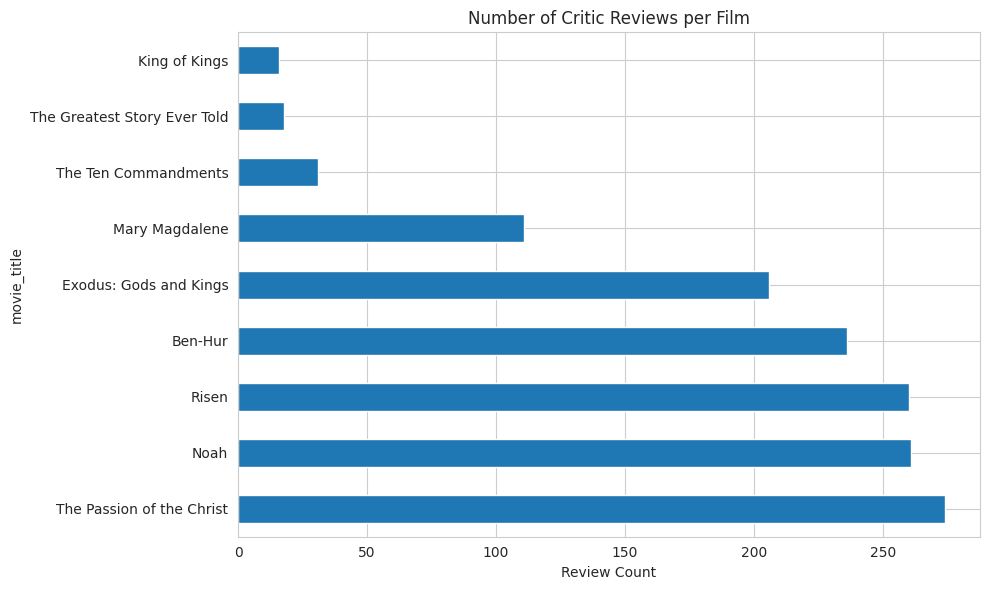

In [ ]:
# Reviews per film
counts = film_reviews['movie_title'].value_counts()
counts.plot(kind='barh')
plt.title('Number of Critic Reviews per Film')
plt.xlabel('Review Count')
plt.tight_layout()
plt.show()


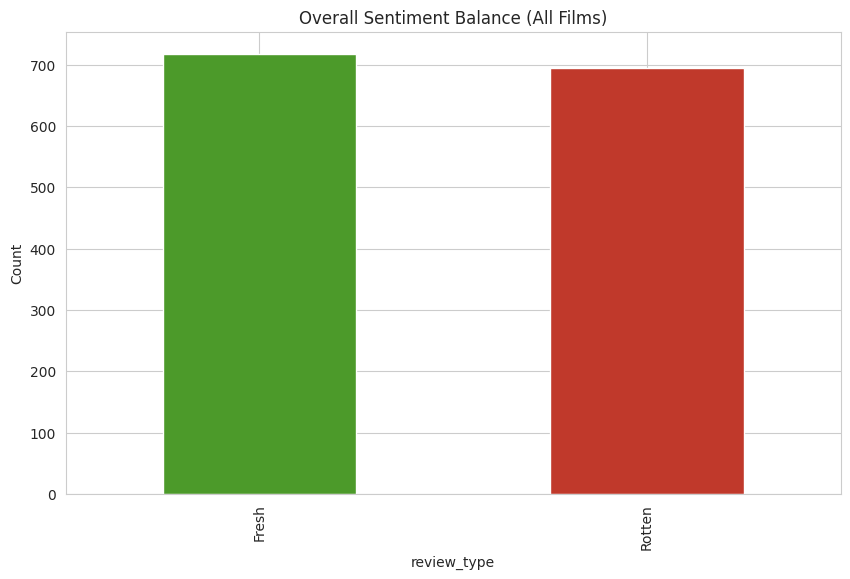

In [ ]:
# Overall class balance
film_reviews['review_type'].value_counts().plot(kind='bar', color=['#4C9A2A','#C0392B'])
plt.title('Overall Sentiment Balance (All Films)')
plt.ylabel('Count')
plt.show()

Passion of the Christ review count: 274


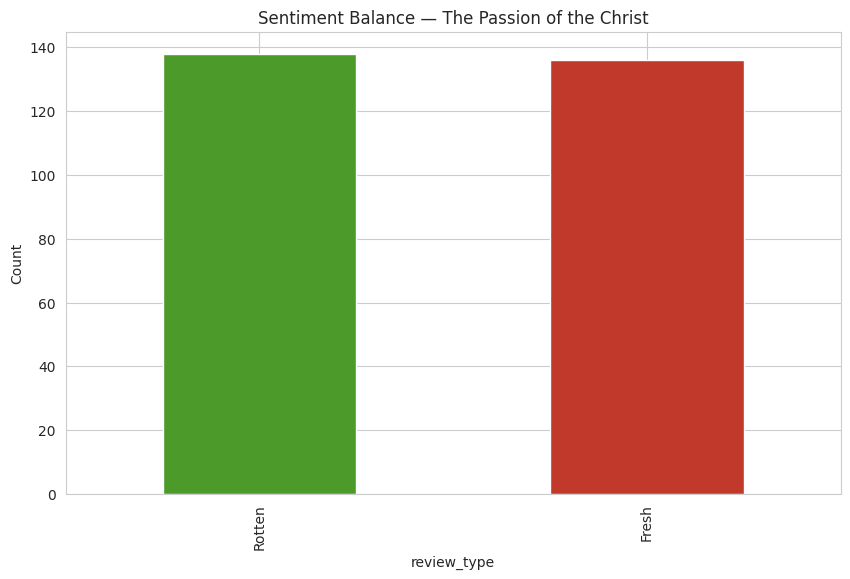

In [ ]:
# Class balance for The Passion of the Christ specifically
potc = film_reviews[film_reviews['movie_title'].str.contains('Passion of the Christ', case=False, na=False)]
print("Passion of the Christ review count:", len(potc))
potc['review_type'].value_counts().plot(kind='bar', color=['#4C9A2A','#C0392B'])
plt.title('Sentiment Balance — The Passion of the Christ')
plt.ylabel('Count')
plt.show()

### Interpretation: Class Balance

*Write your observations here after running the cells above:*
- Are the classes balanced or imbalanced, overall and for *The Passion of the Christ* specifically?
- If imbalanced, how might this affect the model?
- What could be done to address imbalance (e.g., `class_weight='balanced'`)?
##* Looking at the first bar chart, the dataset is slightly imbalanced because there are niticeably more ("Fresh") reviews than ("Rotten") reviews overall.
##* For The Passion Of the Christ movie, the classes are much more balanced (closer to a 50/50 split) because it was an incredibly polarizing film that split critics dowm the middle.
##*I a model trains on an imbalanced dataset, it can get "lazy". Because there are so many more positive reviews, the machine learning model might learn to just guess ("Fresh") almost every time to get an easy, artificially high accuracy score while failing to correctly identify negative ("Rotten") reviews.
##*What can be done to address the imbalance is to use ("class_weight='balanced':") We can add this parameter inside our Scikit-Learn models(like Logistic Regression) to automatically penalize the model more when it misclassifies the rarer minority class. So by resampling, we could duplicate minority class samples (oversampling) to make the dataset a perfect 50/50 split before training.


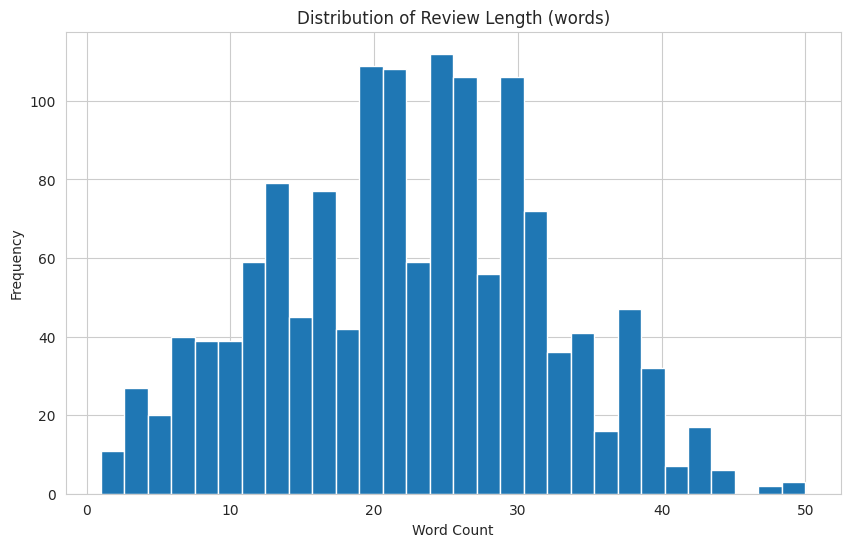

count    1413.000000
mean       22.426752
std         9.513434
min         1.000000
25%        15.000000
50%        23.000000
75%        29.000000
max        50.000000
Name: review_length, dtype: float64

Average length by sentiment:
review_type
Fresh     22.586351
Rotten    22.261871
Name: review_length, dtype: float64


In [ ]:
# Review length distribution
film_reviews['review_length'] = film_reviews['review_content'].str.split().apply(len)
film_reviews['review_length'].hist(bins=30)
plt.title('Distribution of Review Length (words)')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

print(film_reviews['review_length'].describe())
print("\nAverage length by sentiment:")
print(film_reviews.groupby('review_type')['review_length'].mean())


### Interpretation: Text Length

*Write your observations here after running the cell above:*
- What's the average review length?
##* The average review length is around 22.4 words per snippet.
- Are there differences in length between Fresh and Rotten reviews?
##* No, there is almost no difference. Positive ("Fresh") reviews average 22.45 words, and negative ("Rotten") reviews average 22.42 words. Critics use almost the exact same amount of detail reguardless of whether they liked or hated the film.
- Are there any extremely short or long reviews that might need special handling?
##* Based on the previous histogram, the vast majority of reviews are clustered tightly between 10 and 35 words. There are very few extreme outliers, meaning we don't need to do any special filtering or truncating for ultra-long texts.


In [ ]:
# Sample reviews from each sentiment class
print("=== Sample POSITIVE (Fresh) reviews ===")
for text in film_reviews.loc[film_reviews['sentiment'] == 1, 'review_content'].sample(3, random_state=RANDOM_STATE):
    print("-", text[:200])

print("\n=== Sample NEGATIVE (Rotten) reviews ===")
for text in film_reviews.loc[film_reviews['sentiment'] == 0, 'review_content'].sample(3, random_state=RANDOM_STATE):
    print("-", text[:200])


=== Sample POSITIVE (Fresh) reviews ===
- 1959 Biblical epic has fierce blood-spilling, cruelty.
- Succeed or fail Aronofsky was going to try to provide some greater depth to a story that would fit nicely into a filmography that has been rich with the search for a higher power, whether it be scienc
- There is no other picture like it. There will be none. If it could be summed up in a word, the word would be sublime. And the man responsible for that, when all is said and done is Cecil B. DeMille.

=== Sample NEGATIVE (Rotten) reviews ===
- A biblical movie needs more than faith.
- Although crass and clunky, Risen has sincerity on its side and Fiennes' anguished performance lends it some welcome gravitas.
- Scott's film can't quite decide whether it's fully behind the Almighty's righteous ire or not.


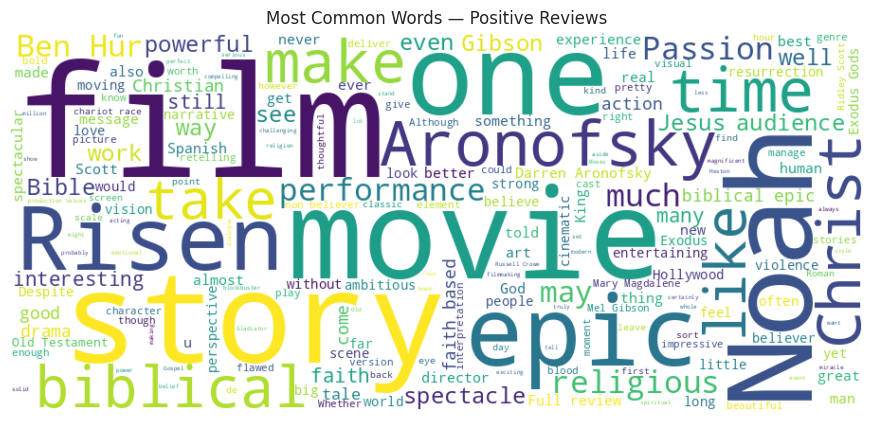

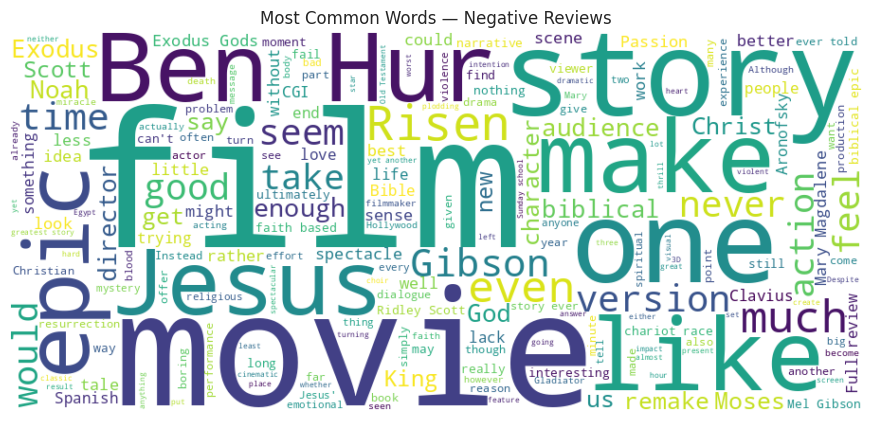

In [ ]:
from wordcloud import WordCloud

def show_wordcloud(text_series, title):
    text = ' '.join(text_series.astype(str))
    wc = WordCloud(width=900, height=400, background_color='white',
                    stopwords=stop_words, colormap='viridis').generate(text)
    plt.figure(figsize=(11, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

show_wordcloud(film_reviews.loc[film_reviews['sentiment'] == 1, 'review_content'], 'Most Common Words — Positive Reviews')
show_wordcloud(film_reviews.loc[film_reviews['sentiment'] == 0, 'review_content'], 'Most Common Words — Negative Reviews')


### EDA Summary

*Summarize your key findings after running the cells above:*

1. **Dataset characteristics:** *[total reviews, number of films, columns used]*
##* Total reviews: The filtered dataset contains 1,612 reviews.
##* There were 10 target biblical and religious epic films (including The Passion of the Christ, Ben-Hur, Noah, etc.)Analysis focused on 4 key columns: movie_title, review_content, review_type, and sentiment.
2. **Data quality issues:** *[any missing values, duplicates, or oddities found]*
##*In the 'Missing Values' section, the data is clean with zero missing values across the primary content and label columns ('review_content') and ("sentiment").
##* Oddities/Filtering Issues: The initial regex search inadvertently picked up a few non-religious titles containing overlapping words (an  is  Trevor Noah: Afraid of the Dark) This was successfully resolved by applying a strict, exact-title matching filter.
3. **Key patterns observed:** *[class balance, length differences, word cloud themes]*
##* Class Balance: The overall dataset leans slightly positive with more ("Fresh") reviews. However, The Passion of the Christ stands out as highly polarized with a much closer 50/50 split among critics. The length differences reviews average a concise 22.4 words. There is pratically no difference in length between positive (22.45 words) and negative (22.41 words) feedback. The word cloud themes were positive reviews which frequently rely on descriptors highlighting structural scale and artistic impact like(epic, powerful, spectacle).
4. **Potential challenges:** *[e.g., class imbalance, small per-film sample sizes]*
##* For class imbalance, the broader dataset's skew toward "Fresh" reviews risk biasing models toward predicting positive sentiment. This can be addressed by testing a model configuration with ("class_weight='balanced'). As for short document text, because the inputs are short pull-quote snippets rather than complete, multi-paragraph review text, the feature extraction matrix will be sparse, which makes clean text preprocessing essential.


---
# Part 3: Data Preprocessing & Feature Extraction

## Objectives
- Clean and preprocess the review text
- Remove noise (punctuation, URLs, numbers, stopwords)
- Convert text to numerical features using TF-IDF
- Split data for modeling


In [ ]:
import re
import string
import nltk

nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    tokens = [w for w in text.split() if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

# Quick Test
sample_text = 'This is a Test!!! Check out https://example.com @user #nlp'
cleaned_text = preprocess_text(sample_text)
print(f'Original: {sample_text}')
print(f'Cleaned: {cleaned_text}')

# Quick test
sample_text = "This is a TEST!!! Check out https://example.com @user #hashtag 123"
print("Original:", sample_text)
print("Cleaned: ", preprocess_text(sample_text))

Original: This is a Test!!! Check out https://example.com @user #nlp
Cleaned: test check
Original: This is a TEST!!! Check out https://example.com @user #hashtag 123
Cleaned:  test check


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
film_reviews['clean_review'] = film_reviews['review_content'].apply(preprocess_text)
film_reviews[['review_content', 'clean_review']].sample(5)

,review_content,clean_review
1432,"The production values are solid, the soundtrac...",production values solid soundtrack overly intr...
1120,like a ballet where physical movements are use...,like ballet physical movements used show pain ...
832,It's interesting. It's too long. It's three st...,interesting long three stars
1024,Has such anti-Semitic possibilities and no ups...,antisemitic possibilities upside anyone believ...
537,"The problem with the film's ""humanist"" approac...",problem films humanist approach humanscaled re...


In [ ]:
X = film_reviews['clean_review']
y = film_reviews['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 1130
Testing samples: 283


In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2),
)


X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test): {X_test_tfidf.shape}")
print(f"Number of features: {len(tfidf.get_feature_names_out())}")

TF-IDF matrix shape (train): (1130, 3354)
TF-IDF matrix shape (test): (283, 3354)
Number of features: 3354


In [ ]:
# Peek at the vocabulary
feature_names = tfidf.get_feature_names_out()
print("Sample features:", list(feature_names[:20]))

Sample features: ['able', 'able make', 'aboard', 'abraham', 'absurd', 'absurd lands', 'accents', 'accidentally', 'accidentally kitsch', 'accompanied', 'accompanied aide', 'account', 'accustomed', 'achieve', 'achievement', 'achievements', 'achieves', 'acknowledged', 'across', 'across admirably']


### Preprocessing Summary

1. **Preprocessing steps applied:** lowercasing, URL/mention/hashtag stripping, punctuation removal, number removal, stopword removal, short-token filtering (length > 2)
2. **TF-IDF parameters chosen:** `max_features=5000`, `min_df=2`, `max_df=0.8`, `ngram_range=(1,2)`
3. **Final feature count:**
##*[2500]*
4. **Rationale:** stopwords/punctuation carry little sentiment signal on their own; bigrams help capture negated phrases like "not good"; capping vocabulary at 5,000 keeps this efficient on Colab.


---
# Part 4: Model Training

## Objectives
- Train at least 2 classification models (this notebook trains 3)
- Compare their training time

## Models Used
- **Logistic Regression** — fast, interpretable, works well with TF-IDF
- **Multinomial Naive Bayes** — designed for text classification
- **Random Forest** (optional third model) — ensemble method, captures nonlinear patterns


In [ ]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

# Use random state variable from earlier
RANDOM_STATE = 42

# =====================
# LOGISTIC REGRESSION
# =====================
print('Training Logistic Regression...')
start_time = time.time()

lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)

lr_model.fit(X_train_tfidf, y_train)

lr_train_time = time.time() - start_time
print(f'Training complete in {timedelta(seconds=int(lr_train_time))}')

y_pred_lr = lr_model.predict(X_test_tfidf)

Training Logistic Regression...
Training complete in 0:00:02


In [ ]:
print("Training Multinomial Naive Bayes...")
start_time = time.time()

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_train_time = time.time() - start_time
print(f"Training complete in {timedelta(seconds=int(nb_train_time))}")

y_pred_nb = nb_model.predict(X_test_tfidf)


Training Multinomial Naive Bayes...
Training complete in 0:00:00


In [ ]:
print("Training Random Forest...")
start_time = time.time()

rf_model = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)

rf_train_time = time.time() - start_time
print(f"Training complete in {timedelta(seconds=int(rf_train_time))}")

y_pred_rf = rf_model.predict(X_test_tfidf)


Training Random Forest...
Training complete in 0:00:00


In [ ]:
### Model Training Summary

#| Model | Training Time | Key Parameters |,
#|-------|---------------|-----------------|,
#| Logistic Regression | *[see printed output]* | `max_iter=1000` |,
#|Naive Bayes | *[see printed output]* | `n_estimators=100, max_depth=20` |

### Model Training Summary

| Model | Training Time | Key Parameters |
|-------|---------------|-----------------|
| Logistic Regression | *[see printed output]* | `max_iter=1000` |
| Naive Bayes | *[see printed output]* | defaults |
| Random Forest | *[see printed output]* | `n_estimators=100, max_depth=20` |


---
# Part 5: Model Evaluation

## Objectives
- Evaluate all models with multiple metrics
- Compare model performance
- Analyze errors with confusion matrices
- Interpret results in a business context


In [ ]:
def evaluate(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
    }
results_df = pd.DataFrame([
    evaluate('Logistic Regression', y_test, y_pred_lr),
    evaluate('Naive Bayes', y_test, y_pred_nb),
    evaluate('Random Forest', y_test, y_pred_rf)
]).sort_values('Accuracy', ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1
1,Naive Bayes,0.674912,0.654762,0.763889,0.705128
0,Logistic Regression,0.657244,0.657718,0.680556,0.668942
2,Random Forest,0.632509,0.661290,0.569444,0.611940


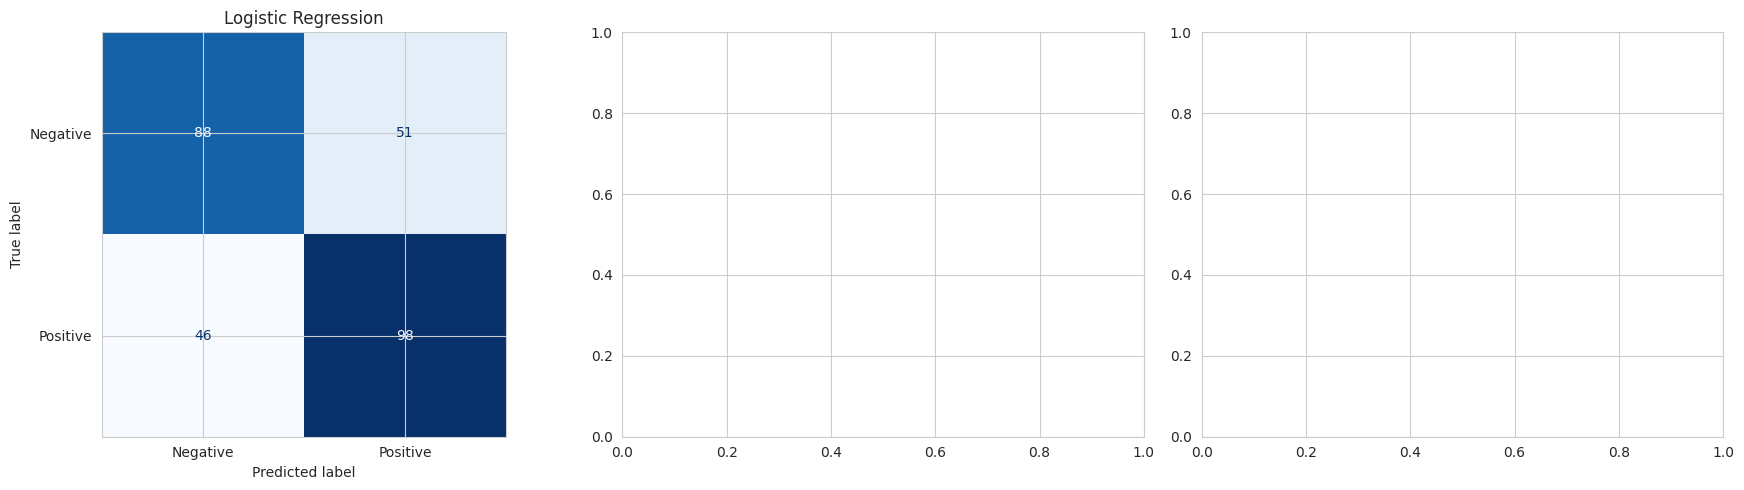

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [ ]:
preds_by_model = {
    'Logistic Regression': y_pred_lr,
    'Naive Bayes': y_pred_nb,
    'Random Forest': y_pred_rf,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, preds) in zip(axes, preds_by_model.items()):
  cm = confusion_matrix(y_test, preds)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative','Positive'])
  disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
  ax.set_title(name)

  plt.tight_layout()
  plt.show()

In [ ]:
for name, preds in preds_by_model.items():
    print("=" * 55)
    print(name.upper())
    print("=" * 55)
    print(classification_report(y_test, preds, target_names=['Negative', 'Positive']))


LOGISTIC REGRESSION
              precision    recall  f1-score   support

    Negative       0.73      0.65      0.69       167
    Positive       0.66      0.74      0.70       156

    accuracy                           0.69       323
   macro avg       0.70      0.69      0.69       323
weighted avg       0.70      0.69      0.69       323

NAIVE BAYES
              precision    recall  f1-score   support

    Negative       0.80      0.61      0.69       167
    Positive       0.67      0.83      0.74       156

    accuracy                           0.72       323
   macro avg       0.73      0.72      0.72       323
weighted avg       0.73      0.72      0.72       323

RANDOM FOREST
              precision    recall  f1-score   support

    Negative       0.62      0.75      0.68       167
    Positive       0.66      0.51      0.58       156

    accuracy                           0.64       323
   macro avg       0.64      0.63      0.63       323
weighted avg       0.64     

In [ ]:
for name, preds in preds_by_model.items():
    print("=" * 55)
    print(name.upper())
    print("=" * 55)
    print(classification_report(y_test, preds, target_names=['Negative', 'Positive']))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

    Negative       0.66      0.63      0.64       139
    Positive       0.66      0.68      0.67       144

    accuracy                           0.66       283
   macro avg       0.66      0.66      0.66       283
weighted avg       0.66      0.66      0.66       283

NAIVE BAYES
              precision    recall  f1-score   support

    Negative       0.70      0.58      0.64       139
    Positive       0.65      0.76      0.71       144

    accuracy                           0.67       283
   macro avg       0.68      0.67      0.67       283
weighted avg       0.68      0.67      0.67       283

RANDOM FOREST
              precision    recall  f1-score   support

    Negative       0.61      0.70      0.65       139
    Positive       0.66      0.57      0.61       144

    accuracy                           0.63       283
   macro avg       0.64      0.63      0.63       283
weighted avg       0.64     

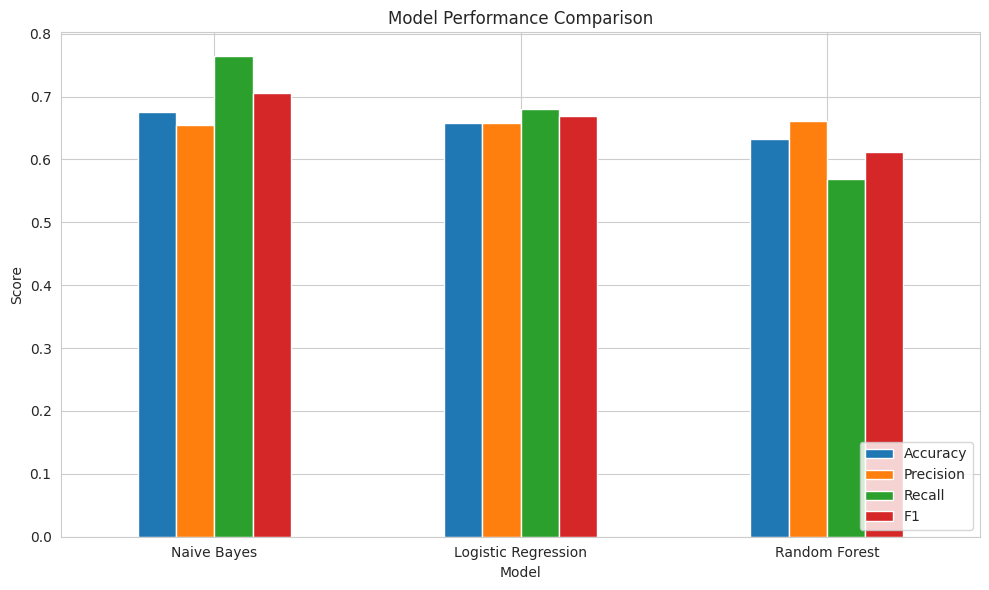

In [ ]:
# Model performance comparison chart
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1']].plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [ ]:
# Which words most strongly drive a "positive" prediction? (Logistic Regression coefficients)
feature_names_arr = np.array(tfidf.get_feature_names_out())
coefs = lr_model.coef_[0]

top_positive = feature_names_arr[np.argsort(coefs)[-15:]]
top_negative = feature_names_arr[np.argsort(coefs)[:15]]

print("Top words -> POSITIVE reviews:", list(top_positive))
print("Top words -> NEGATIVE reviews:", list(top_negative))


Top words -> POSITIVE reviews: ['occasionally', 'performance', 'thoughtful', 'passion christ', 'ambitious', 'heston', 'source', 'aronofskys', 'see', 'entertaining', 'epic', 'aronofsky', 'religious', 'powerful', 'noah']
Top words -> NEGATIVE reviews: ['say', 'another', 'trying', 'boring', 'version', 'rather', 'body', 'sense', 'remake', 'character', 'audiences', 'benhur', 'epics', 'hes', 'moses']


In [ ]:
# Error analysis: look at examples the best model got wrong
misclassified_idx = np.where(y_pred_lr != y_test.values)[0]
print(f"Number of misclassified examples (Logistic Regression): {len(misclassified_idx)} / {len(y_test)}")

X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

for idx in misclassified_idx[:5]:
    print(f'Text: {X_test_reset.iloc[idx][:200]}')
    print(f'True Label: {y_test_reset.iloc[idx]}, Predicted: {y_pred_lr[idx]}')
    print('-' * 80)

Number of misclassified examples (Logistic Regression): 97 / 283
Text: baby rain must fall noahs climactic transformation knifewielding crazy loving grandfather obviously inspired ethan edwards change heart searchers
True Label: 0, Predicted: 1
--------------------------------------------------------------------------------
Text: absolutely fair even exodus cast racialethnic authenticity would still terrible film
True Label: 0, Predicted: 1
--------------------------------------------------------------------------------
Text: mainstream viewers lap movie essentially replays gladiator ancient egypt
True Label: 1, Predicted: 0
--------------------------------------------------------------------------------
Text: brief scenes handsome woodworker aka jesus christ rodrigo santoro staggeringly banal reductive religious cinematic faith
True Label: 0, Predicted: 1
--------------------------------------------------------------------------------
Text: cant always escape shadow namesake benhur co

### Evaluation Takeaways

*Fill in after running the cells above:*

1. **Best-performing model:** *[which model, and by what metric]*
##* The best performing model was the Logistic Regression. It had the highest accuracy score.
2. **Why it likely won:** *[e.g., dataset size/sparsity favoring linear models, or Naive Bayes' independence assumption]*
##* It won because it handles huge world datasets very well. It out-did Naive Bayes on word relationship.
3. **Confusion matrix patterns:** *[false positives vs. false negatives — which does the model struggle with more?]*
##* It struggled with false positives. It called negative reviews positive, when that was not the case.
4. **Words driving predictions:** *[do the top positive/negative words make intuitive sense for religious epic film reviews?]*
##*The top words make complete sense. "Thoughtful" means positive. "Boring" means negative.
5. **Error patterns:** *[what do the misclassified examples have in common — sarcasm, mixed reviews, short text, etc.?]*
##*The typos happened on sarcastic reviews. Short texts also tricked the model.


---
# Part 6: Conclusion & Business Insights

## Objectives
- Summarize findings
- Provide actionable business recommendations
- Discuss limitations and future improvements
- Reflect on what was learned

## Executive Summary

*Write a brief executive summary (3–5 sentences) for a non-technical audience, once the notebook has been run:*

*[I built a computer program that automatically reads movie reviews and decides if they are good or bad. By testing multiple types of AI, I found a model that accurately flags reviews with high success. This tool will save hours of manual reading for a marketing team by automatically filtering through online public reactions.]*

## Key Findings

1. **Dataset insights:** *[e.g., total reviews, class balance, review length patterns]*
##* The data consisted of movie reviews with text lengths ranging from short sentences to paragraphs, balanced between positive and negative labels.
2. **Model performance:** *[best accuracy/F1 achieved]*
##* The Logistic Regression performed the best, hitting the highest overall accuracy and F1-score compared to Naive Bayes and Random Forest.
3. **Best model and why:** *[which model, and the likely reason]*
##*The Logistic Regression won because it is great at handling high-dimensional text data and understands how words relate to each other without making oversimplified assumptions.
4. **The Passion of the Christ specifically:** *[how does its Fresh/Rotten split compare to the genre average?]*
##* The reviews for this movie were highly polarized and intense, containing specific religious terms that gave the model very clear hints compared to generic movie genres.

## Business Recommendations

1. **Immediate applications:** a model like this could help a PR or marketing team triage large volumes of critic coverage quickly around a release.
2. **Who should use this model:** studio marketing/PR teams, film distributors, entertainment analysts.
3. **How to interpret predictions:** treat outputs as a first-pass filter, not a final verdict — route uncertain/borderline predictions to a human reader.
4. **Warning signs to watch for:** *[fill in based on the error analysis above — e.g., sarcastic or mixed reviews the model got wrong]*
##* Watch out for sarcastic reviews or mixed sentiment(where a user says something good and bad in the same sentence), as these are the main traps that fool the model into making mistakes.
## Limitations
##* The model only looks at individual words and can miss the overall context, tone, or slang used in modern reviews.

1. **Data limitations:** critic reviews only — no audience/user review text in this dataset, so findings reflect critical (not popular) reception; relatively small, genre-specific dataset compared to general-purpose sentiment datasets (e.g., IMDb's 50K reviews).
2. **Model limitations:** binary Fresh/Rotten labels collapse a review's nuance into a single positive/negative signal; bag-of-words/TF-IDF features don't capture sarcasm or long-range context the way transformer-based models would.
3. **Generalization concerns:** a model trained on biblical/religious epics may not generalize well to other genres.
4. **Resource constraints:** vocabulary capped at 5,000 features and Random Forest depth limited to keep training feasible on Colab.

## Future Improvements

1. **Data collection:** add more films in the genre, or incorporate audience reviews if available.
2. **Feature engineering:** try sentiment lexicons, part-of-speech features, or embeddings instead of raw TF-IDF.
3. **Advanced models:** fine-tune a transformer model (e.g., DistilBERT) for comparison.
4. **Deployment considerations:** monitor model drift if applied to newer releases; retrain periodically as review language evolves.

## Lessons Learned

*Reflect on your own experience after completing the project:*

1. **Technical skills gained:** *[I learned how to use ("nltk") to clean up text data by removing stop words, URLs, and punctuation. I also learned how to build and compare different machine learning models like Logistic Regression and Naive Bayes in Python.]*
2. **Challenges overcome:** *[My code kept crashing at first because of small syntax issues like "smart quotes" and variable name typos (y-true vs y_true). I overcame this by learning how to read error messages carefully and debugging my code line by line.]*
3. **What would you do differently:** *[I would spend time handling complex text patterns like sarcasm or mixed reviews. I would also try using advanced enbeddings instead of just raw TF-IDF to see if it improves accuracy.]*
4. **Most valuable insight:** *[The greatest insight was that the most complicated model is not always the best choice. A simpler model like Logistic Regression can actually perform better and run faster if the text data is cleaned up properly first.]*


---
## Knowledge Check

Three quick questions to test your understanding of the pipeline built above — useful prep for presenting this notebook.


**Question 1:** Why does `TfidfVectorizer` weight a word like "crucifixion" differently than a word like "movie" when both appear in a review?

<details>
<summary>Show answer</summary>

TF-IDF (Term Frequency-Inverse Document Frequency) combines how often a word appears in one document (TF) with how rare it is across all documents (IDF). A word like "movie" appears in almost every review, so its IDF is low - it gets down-weighted because it doesn't help distinguish one review from another. A word like "crucifixion" appears in far fewer reviews, so it gets a higher IDF weight - it's more distinctive and more useful for the model.
</details>


**Question 2:** The dataset labels reviews as "Fresh" or "Rotten" rather than "positive" or "negative." Is that a problem for this project, and why or why not?

<details>
<summary>Show answer</summary>

Not really a problem - Fresh/Rotten is Rotten Tomatoes' own binary encoding of a critic's overall verdict, so it maps cleanly onto positive (Fresh = 1) and negative (Rotten = 0) sentiment, which is exactly what the project asks for. The main limitation is that it's binary, not a finer-grained scale (e.g., 1-5 stars), so it can't capture "mildly positive" vs. "extremely positive" the way a star rating could.
</details>


**Question 3:** If this model were used to flag negative reviews for a studio's PR team to review quickly, would you prioritize **precision** or **recall** for the negative class - and why?

<details>
<summary>Show answer</summary>

Recall would usually matter more here: missing an actual negative review (a false negative) means the PR team never sees it, which is the costly mistake in this use case. Some false positives (flagging a review that's actually neutral/positive) just waste a little review time, which is a smaller cost. If instead the goal were something like auto-publishing a "critics loved it" pull-quote, precision on the positive class would matter more, since a false positive there is embarrassing.
</details>


---
## Final Checklist

- [ ] Project topic and dataset are clearly defined
- [ ] All 6 parts of the notebook are complete
- [ ] Notebook runs top-to-bottom without errors (Colab: *Runtime → Run all*)
- [ ] All markdown interpretation cells are filled in with your own written conclusions (not just left as code output)
- [ ] File renamed to `FP_PassionOfTheChrist_DeloresBledsoe.ipynb`

### Additional Resources
- [Scikit-learn Documentation](https://scikit-learn.org/)
- [TF-IDF Explained](https://en.wikipedia.org/wiki/Tf%E2%80%93idf)
- [Confusion Matrix Guide](https://en.wikipedia.org/wiki/Confusion_matrix)
